In [1]:
pip install yfinance beautifulsoup4 requests matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
ticker = 'TSLA'
tesla_data = yf.download(ticker, start='2023-01-01', end='2024-01-01')
tesla_data.head()


[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-01-03,118.470001,118.800003,104.639999,108.099998,108.099998,231402800
2023-01-04,109.110001,114.589996,107.519997,113.639999,113.639999,180389000
2023-01-05,110.510002,111.750000,107.160004,110.339996,110.339996,157986300
2023-01-06,103.000000,114.389999,101.809998,113.059998,113.059998,220911100
2023-01-09,118.959999,123.519997,117.110001,119.769997,119.769997,190284000


In [7]:
import requests
from bs4 import BeautifulSoup

# URL for Tesla's financials
url = 'https://finance.yahoo.com/quote/TSLA/financials'

# Send a GET request
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Print out the first 500 characters of the page content to see the HTML structure
print(soup.prettify()[:500])

# Adjust the selector based on the observed HTML structure
# For example, if revenue data is inside a table, you might look for <table> elements or specific classes
# You may need to use different attributes or tags
# Example placeholder:
revenue_elements = soup.find_all('span', {'class': 'Fz(s) Ta(end) Pstart(15px)'})  # Update this selector

if revenue_elements:
    revenue = revenue_elements[0].text
    print('Tesla Revenue:', revenue)
else:
    print('No revenue data found. Check the HTML structure and update the selector.')


<!DOCTYPE html>
<html lang="en-us">
 <head>
  <meta content="text/html; charset=utf-8" http-equiv="content-type"/>
  <meta charset="utf-8"/>
  <title>
   Yahoo
  </title>
  <meta content="width=device-width,initial-scale=1,minimal-ui" name="viewport"/>
  <meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/>
  <style>
   html {
      height: 100%;
  }
  body {
      background: #fafafc url(https://s.yimg.com/nn/img/sad-panda-201402200631.png) 50% 50%;
      background-size: cover;
     
No revenue data found. Check the HTML structure and update the selector.


In [9]:
!pip install yfinance==0.2.38
!pip install pandas==2.2.2
!pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/73.0 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/73.0 kB ? eta -:--:--
   ---------------------- ----------------- 41.0/73.0 kB 487.6 kB/s eta 0:00:01
   ---------------------------------------- 73.0/73.0 kB 667.6 kB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.41
    Uninstalling yfinance-0.2.41:
      Successfully uninstalled yfinance-0.2.41


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.6 MB 1.9 MB/s eta 0:00:07
   ---------------------------------------- 0.1/11.6 MB 1.1 MB/s eta 0:00:11
    --------------------------------------- 0.2/11.6 MB 1.8 MB/s eta 0:00:07
   - -------------------------------------- 0.3/11.6 MB 2.3 MB/s eta 0:00:06
   -- ------------------------------------- 0.6/11.6 MB 3.4 MB/s eta 0:00:04
   --- ------------------------------------ 1.1/11.6 MB 4.2 MB/s eta 0:00:03
   --- ------------------------------------ 1.1/11.6 MB 4.2 MB/s eta 0:00:03
   ---- ----------------------------------- 1.4/11.6 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 2.0/11.6 MB 5.0 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.6 MB 5.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.3/11.6 MB 4.8 MB/s eta 0:00:02
   --

In [11]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [13]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [15]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Historical Share Price", "Historical Revenue"), vertical_spacing = .3)
    stock_data_specific = stock_data[stock_data.Date <= '2021--06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_data_specific.Date), y=stock_data_specific.Close.astype("float"), name="Share Price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_data_specific.Date), y=revenue_data_specific.Revenue.astype("float"), name="Revenue"), row=2, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    fig.update_layout(showlegend=False,
    height=900,
    title=stock,
    xaxis_rangeslider_visible=True)
    fig.show()

In [17]:
import yfinance as yf
import pandas as pd
tesla = yf.Ticker("TSLA")
tesla_stock_data = tesla.history(period="max")
tesla_stock_data.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [21]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"")

In [23]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [25]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, 'html.parser')
tables = soup.find_all('table')
tesla_revenue = pd.read_html(str(tables))[0]
tesla_revenue.columns = ['Date', 'Revenue']
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"", regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

tesla_revenue.head()


,Date,Revenue
0,2021,53823
1,2020,31536
2,2019,24578
3,2018,21461
4,2017,11759


In [27]:
import yfinance as yf
import pandas as pd
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712708,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603296,1.662209,6892800,0.0,0.0


In [29]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url).text
soup = BeautifulSoup(html_data_2, 'html.parser')
tables = soup.find_all('table')
gme_revenue = pd.read_html(str(tables))[1]
gme_revenue.columns = ['Date', 'Revenue']
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

gme_revenue.head()


,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


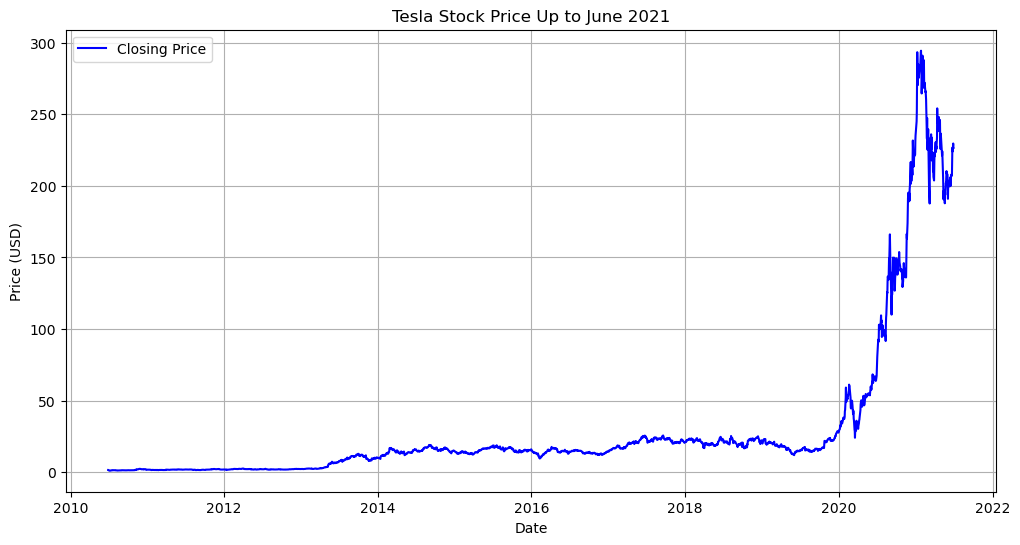

In [31]:
import matplotlib.pyplot as plt
import yfinance as yf
tesla = yf.Ticker("TSLA")
tesla_stock_data = tesla.history(period="max")
tesla_stock_data = tesla_stock_data[:'2021-06-30']
plt.figure(figsize=(12, 6))
plt.plot(tesla_stock_data.index, tesla_stock_data['Close'], label='Closing Price', color='blue')
plt.title('Tesla Stock Price Up to June 2021')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.show()


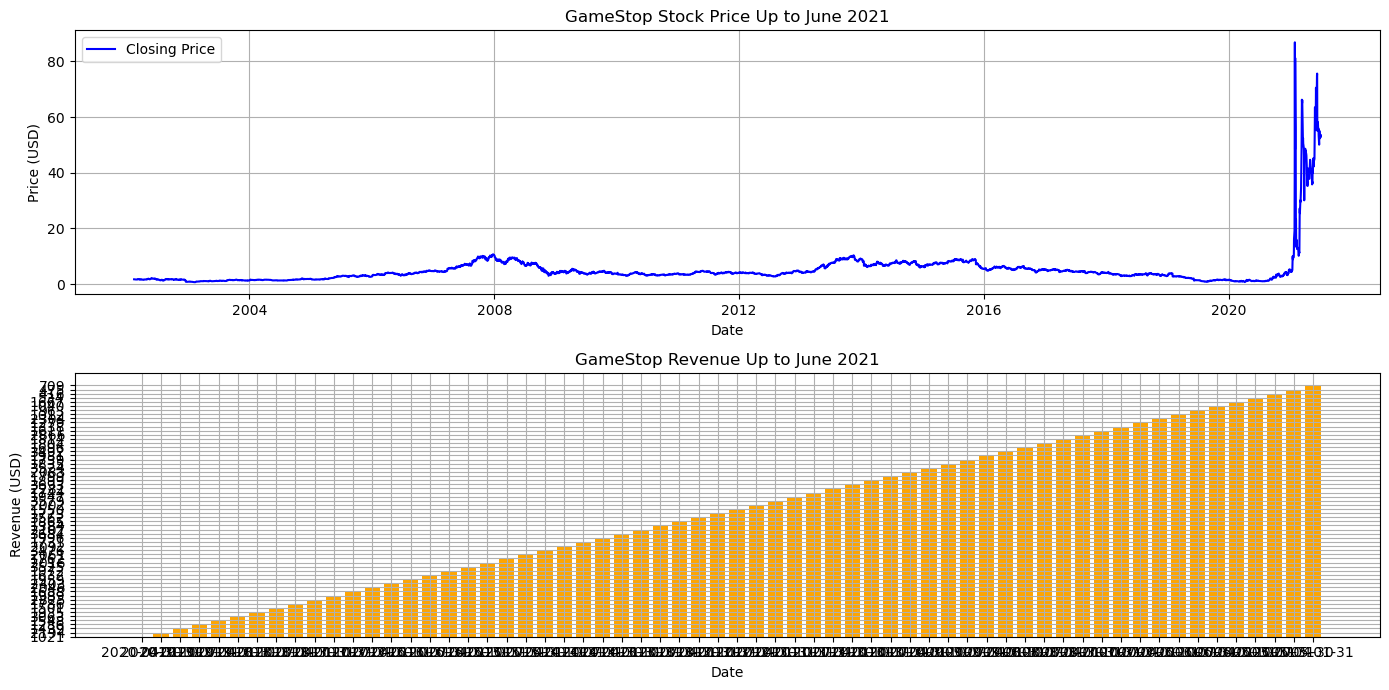

In [33]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
def make_graph(stock_data, revenue_data, title):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 7))
    plt.subplot(2, 1, 1)
    plt.plot(stock_data['Date'], stock_data['Close'], label='Closing Price', color='blue')
    plt.title(f'{title} Stock Price Up to June 2021')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.subplot(2, 1, 2)
    plt.bar(revenue_data['Date'], revenue_data['Revenue'], color='orange')
    plt.title(f'{title} Revenue Up to June 2021')
    plt.xlabel('Date')
    plt.ylabel('Revenue (USD)')
    plt.grid(True)
plt.tight_layout()
    plt.show()
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url).text
soup = BeautifulSoup(html_data_2, 'html.parser')
tables = soup.find_all('table')
gme_revenue = pd.read_html(str(tables))[1]
gme_revenue.columns = ['Date', 'Revenue']
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
gme_data = gme_data[gme_data['Date'] <= '2021-06-30']
gme_revenue = gme_revenue[gme_revenue['Date'] <= '2021-06-30']
make_graph(gme_data, gme_revenue, 'GameStop')


In [35]:
# Display the last five rows of the tesla_revenue dataframe
tesla_revenue.tail()


,Date,Revenue
8,2013,2013
9,2012,413
10,2011,204
11,2010,117
12,2009,112


In [37]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709
